# Summary
This notebook details the exploratory data analysis and data preprocessing procedures for the [Lending Club dataset](https://www.kaggle.com/datasets/wordsforthewise/lending-club). Our goal is to predict the probability of default of loans based on 110 features of each loan (e.g. FICO score, number of credit lines, loan amount, etc.). 

The exploratory data analysis stage of our work involved analyzing the distributions of individual variables and the correlations between them, as well as producing graphs/visualizations of select features. The following are some noteworthy characteristics of the Lending Club dataset that we discovered:
* The distribution of the target feature (fully paid/default) is highly imbalanced, with defaulted loans making up ~20% of the dataset. 
* There is low correlation between approved loan amount and FICO score, which deviates from the general trend of institutional loans. 
* Lending Club loans are all either on a 36 month or 60 month term. Default rate is significantly higher for 60 month terms. This is expected as the longer the duration of a loan, the more the borrower is likely to vary in terms of defaulting behavior. 
* In terms of home ownership status, borrowers who rent had the highest rate of default. 
* Loans with a stated purpose of "small business" had the highest rate of default. This is expected as investments in personal businesses are risky, and if the business fails, default is highly probable. Loans for renewable energy had the second highest rate of default, which can be explained by a similar line of reasoning. 

| Purpose              | Default rate |
|----------------------|--------------|
| small_business       | 0.297094     |
| renewable_energy     | 0.236870     |
| moving               | 0.233544     |
| house                | 0.218914     |
| medical              | 0.217858     |
| debt_consolidation   | 0.211491     |

* Default rate varied significantly with geography. Mississipi had the highest default rate at 26%, while DC had the lowest default rate at 13%. In terms of zip code, some zip codes had very high default rates, but upon closer inspection, we suspect this may be due to small sample size per zip code. For instance, the zip code prefix 692 (located in Valentine, NE, a rural town), had a 75% default rate, but we found that only 8 borrowers were located in Valentine. 
* Lending Club assigns its own grade (A, B, C, D...) to each loan, which is visible to investors. However, the grades only have a ~0.26 correlation with the actual default status. 

The data preprocessing stage of our work involved removing outliers and correlated variables, imputing missing values, and converting date/time features into numerical features. 

Afterward, various machine learning models were implemented (including hyperparameter tuning) on the processed data. The performance of the two best models are shown in the table below (F1-score is a weighted accuracy score taking into account the imbalanced frequency of default vs. fully paid loans):

| Model         | F1 Score |
|---------------|----------|
| Random Forest | 0.8891   |
| XGBoost       | 0.8904   |

We can obtain feature importances from each model, where importance refers to the weight that the model gives to a feature when outputting its decision. These are the top 5 feature importances for the XGBoost model:

| Feature              | Importance |
|----------------------|------------|
| int_rate             | 0.580458   |
| term                 | 0.096190   |
| dti                  | 0.039274   |
| acc_open_past_24mths | 0.026135   |
| home_ownership       | 0.024560   |

Interest rate seems to be on of the most important indicators of default risk. 

## Directions for future work
Given that our prior work has identified interest rate as one of the most important indicators of default risk, we wonder if the P2P market could be optimized through the perspective of interest rates. If borrowers and lenders are able to negotiate better interest rates, default risk could decrease, and P2P lending may become a more attractive investment. 

# Dependencies

In [1]:
import pandas as pd
import numpy as np

import re

import matplotlib.pyplot as plt
import seaborn as sns
import hvplot.pandas

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, precision_recall_curve

from scipy.stats import pearsonr, chi2_contingency
from itertools import combinations
from statsmodels.stats.proportion import proportion_confint

# Import data

In [2]:
data = pd.read_csv('data/accepted_2007_to_2018Q4.csv')
data.head()

/var/folders/pg/r39s25yx6vn60b24nh6592th0000gn/T/ipykernel_11451/2590996382.py:1: DtypeWarning: Columns (0,19,49,59,118,129,130,131,134,135,136,139,145,146,147) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('data/accepted_2007_to_2018Q4.csv')


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


## Filter target feature: Loan status
We will only consider loans that are fully paid or charged off.

In [3]:
data['loan_status'].value_counts(dropna=False)

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
NaN                                                         33
Name: count, dtype: int64

In [4]:
data = data.loc[data['loan_status'].isin(['Fully Paid', 'Charged Off', 'Default'])]
data.shape

(1345350, 151)

In [5]:
# reclassify all charged off loans as default
data.loc[data['loan_status'] == 'Charged Off', 'loan_status'] = 'Default'

# Feature Selection 
The dataset has 151 features, but not all features are available to lenders at the point of application. The file "LCDataDictionary.xlsx" contains the features that are visible to lenders when viewing applications, which we use to filter the columns of the dataset. 

In [6]:
feature_notes = pd.read_excel('data/LCDataDictionary.xlsx', sheet_name=1)
feature_defs = feature_notes['BrowseNotesFile'].dropna().values # Drop NaN values
feature_notes.head()

,BrowseNotesFile,Description
0,acceptD,The date which the borrower accepted the offer
1,accNowDelinq,The number of accounts on which the borrower i...
2,accOpenPast24Mths,Number of trades opened in past 24 months.
3,addrState,The state provided by the borrower in the loan...
4,all_util,Balance to credit limit on all trades


In [7]:
feature_defs = [re.sub('(?<![0-9_])(?=[A-Z0-9])', '_', x).lower().strip() for x in feature_defs] # Match format to dataset
data_feat = data.columns.values
np.setdiff1d(feature_defs, data_feat) # returns the elements of feature_defs that are not in data_feat

array(['accept_d', 'credit_pull_d', 'effective_int_rate', 'exp_d',
       'exp_default_rate', 'ils_exp_d', 'is_inc_v', 'list_d', 'msa',
       'mths_since_most_recent_inq', 'mths_since_oldest_il_open',
       'mths_since_recent_loan_delinq', 'review_status',
       'review_status_d', 'service_fee_rate', 'verified_status_joint'],
      dtype='<U35')

In [8]:
np.setdiff1d(data_feat, feature_defs) # returns the elements of data_feat that are not in feature_defs

array(['collection_recovery_fee', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'deferral_term', 'funded_amnt_inv',
       'hardship_amount', 'hardship_dpd', 'hardship_end_date',
       'hardship_flag', 'hardship_last_payment_amount', 'hardship_length',
       'hardship_loan_status', 'hardship_payoff_balance_amount',
       'hardship_reason', 'hardship_start_date', 'hardship_status',
       'hardship_type', 'issue_d', 'last_credit_pull_d',
       'last_fico_range_high', 'last_fico_range_low', 'last_pymnt_amnt',
       'last_pymnt_d', 'loan_status', 'mo_sin_old_il_acct',
       'mths_since_recent_bc_dlq', 'mths_since_recent_inq',
       'next_pymnt_d', 'orig_projected_additional_accrued_interest',
       'out_prncp', 'out_prncp_inv', 'payment_plan_start_date',
       'policy_code', 'pymnt_plan', 'recoveries', 'settlement_amount',
       'settlement_date', 'settlement_percentage', 'settlement_status',
       'settlement_term', 'total_pymnt', 'total_pymnt_inv',
       'total

In [9]:
len(feature_defs)

120

In [10]:
wrong = ['is_inc_v', 'mths_since_most_recent_inq', 'mths_since_oldest_il_open',
         'mths_since_recent_loan_delinq', 'verified_status_joint']
correct = ['verification_status', 'mths_since_recent_inq', 'mo_sin_old_il_acct',
           'mths_since_recent_bc_dlq', 'verification_status_joint']

feature_defs = np.setdiff1d(feature_defs, wrong)
feature_defs = np.append(feature_defs, correct)
feature_defs

array(['acc_now_delinq', 'acc_open_past_24mths', 'accept_d', 'addr_state',
       'all_util', 'annual_inc', 'annual_inc_joint', 'application_type',
       'avg_cur_bal', 'bc_open_to_buy', 'bc_util',
       'chargeoff_within_12_mths', 'collections_12_mths_ex_med',
       'credit_pull_d', 'delinq_2yrs', 'delinq_amnt', 'desc',
       'disbursement_method', 'dti', 'dti_joint', 'earliest_cr_line',
       'effective_int_rate', 'emp_length', 'emp_title', 'exp_d',
       'exp_default_rate', 'fico_range_high', 'fico_range_low',
       'funded_amnt', 'grade', 'home_ownership', 'id', 'il_util',
       'ils_exp_d', 'initial_list_status', 'inq_fi', 'inq_last_12m',
       'inq_last_6mths', 'installment', 'int_rate', 'list_d', 'loan_amnt',
       'max_bal_bc', 'member_id', 'mo_sin_old_rev_tl_op',
       'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'msa',
       'mths_since_last_delinq', 'mths_since_last_major_derog',
       'mths_since_last_record', 'mths_since_rcnt_il',
       'mths_since_

In [11]:
avail_feat = np.intersect1d(feature_defs, data_feat)
avail_feat =np.append(avail_feat, ['loan_status'])
X = data[avail_feat].copy()
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1345350 entries, 0 to 2260697
Columns: 110 entries, acc_now_delinq to loan_status
dtypes: float64(89), object(21)
memory usage: 1.1+ GB


# Data Types

In [12]:
# Get a sense of the shape (rows, columns)
X.shape

(1345350, 110)

In [13]:
# View first few records
X.head()

,acc_now_delinq,acc_open_past_24mths,addr_state,all_util,annual_inc,annual_inc_joint,application_type,avg_cur_bal,bc_open_to_buy,bc_util,...,total_bal_il,total_bc_limit,total_cu_tl,total_il_high_credit_limit,total_rev_hi_lim,url,verification_status,verification_status_joint,zip_code,loan_status
0,0.0,4.0,PA,34.0,55000.0,NaN,Individual,20701.0,1506.0,37.2,...,4981.0,2400.0,1.0,13734.0,9300.0,https://lendingclub.com/browse/loanDetail.acti...,Not Verified,NaN,190xx,Fully Paid
1,0.0,4.0,SD,29.0,65000.0,NaN,Individual,9733.0,57830.0,27.1,...,18005.0,79300.0,0.0,24667.0,111800.0,https://lendingclub.com/browse/loanDetail.acti...,Not Verified,NaN,577xx,Fully Paid
2,0.0,6.0,IL,65.0,63000.0,71000.0,Joint App,31617.0,2737.0,55.9,...,10827.0,6200.0,5.0,14877.0,14000.0,https://lendingclub.com/browse/loanDetail.acti...,Not Verified,Not Verified,605xx,Fully Paid
4,0.0,10.0,PA,78.0,104433.0,NaN,Individual,27644.0,4567.0,77.5,...,73839.0,20300.0,1.0,88097.0,34000.0,https://lendingclub.com/browse/loanDetail.acti...,Source Verified,NaN,174xx,Fully Paid
5,0.0,0.0,GA,76.0,34000.0,NaN,Individual,2560.0,844.0,91.0,...,3976.0,9400.0,0.0,4000.0,12900.0,https://lendingclub.com/browse/loanDetail.acti...,Source Verified,NaN,300xx,Fully Paid


In [14]:
# View basic information: data types, non-null counts
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1345350 entries, 0 to 2260697
Columns: 110 entries, acc_now_delinq to loan_status
dtypes: float64(89), object(21)
memory usage: 1.1+ GB


## Numerical features

In [15]:
# View summary statistics for numerical columns
X.describe()

,acc_now_delinq,acc_open_past_24mths,all_util,annual_inc,annual_inc_joint,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,collections_12_mths_ex_med,...,tot_coll_amt,tot_cur_bal,tot_hi_cred_lim,total_acc,total_bal_ex_mort,total_bal_il,total_bc_limit,total_cu_tl,total_il_high_credit_limit,total_rev_hi_lim
count,1.345350e+06,1.298069e+06,537583.000000,1.345350e+06,2.580600e+04,1.277801e+06,1.284205e+06,1.283436e+06,1.345294e+06,1.345294e+06,...,1.277823e+06,1.277823e+06,1.277823e+06,1.345350e+06,1.298069e+06,5.376360e+05,1.298069e+06,537635.000000,1.277823e+06,1.277823e+06
mean,5.045527e-03,4.692894e+00,58.176122,7.624757e+04,1.173799e+05,1.348857e+04,1.018625e+04,5.993925e+01,9.062703e-03,1.713454e-02,...,2.493832e+02,1.411333e+05,1.743873e+05,2.498075e+01,4.966625e+04,3.586176e+04,2.163393e+04,1.609224,4.213322e+04,3.279081e+04
std,7.715997e-02,3.186910e+00,20.935663,6.992485e+04,5.978608e+04,1.628961e+04,1.535073e+04,2.829319e+01,1.097208e-01,1.469180e-01,...,1.106480e+04,1.575473e+05,1.780953e+05,1.199851e+01,4.774364e+04,4.290646e+04,2.155464e+04,2.825033,4.325238e+04,3.664226e+04
min,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,1.100000e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00
25%,0.000000e+00,2.000000e+00,44.000000,4.578000e+04,8.000000e+04,3.101000e+03,1.464000e+03,3.830000e+01,0.000000e+00,0.000000e+00,...,0.000000e+00,2.942300e+04,4.962000e+04,1.600000e+01,2.088600e+04,9.605000e+03,7.800000e+03,0.000000,1.473800e+04,1.400000e+04
50%,0.000000e+00,4.000000e+00,59.000000,6.500000e+04,1.062910e+05,7.407000e+03,4.700000e+03,6.320000e+01,0.000000e+00,0.000000e+00,...,0.000000e+00,8.023100e+04,1.123730e+05,2.300000e+01,3.729500e+04,2.406150e+04,1.510000e+04,0.000000,3.168100e+04,2.410000e+04
75%,0.000000e+00,6.000000e+00,73.000000,9.000000e+04,1.400000e+05,1.871700e+04,1.238300e+04,8.480000e+01,0.000000e+00,0.000000e+00,...,0.000000e+00,2.107150e+05,2.520760e+05,3.200000e+01,6.254800e+04,4.672425e+04,2.810000e+04,2.000000,5.663500e+04,4.060000e+04
max,1.400000e+01,6.400000e+01,198.000000,1.099920e+07,1.837000e+06,9.580840e+05,5.599120e+05,3.396000e+02,1.000000e+01,2.000000e+01,...,9.152545e+06,8.000078e+06,9.999999e+06,1.760000e+02,3.408095e+06,1.711009e+06,1.105500e+06,79.000000,2.101913e+06,9.999999e+06


## Categorical features

In [16]:
X.select_dtypes('object').head()

,addr_state,application_type,desc,disbursement_method,earliest_cr_line,emp_length,emp_title,grade,home_ownership,id,...,purpose,sec_app_earliest_cr_line,sub_grade,term,title,url,verification_status,verification_status_joint,zip_code,loan_status
0,PA,Individual,NaN,Cash,Aug-2003,10+ years,leadman,C,MORTGAGE,68407277,...,debt_consolidation,NaN,C4,36 months,Debt consolidation,https://lendingclub.com/browse/loanDetail.acti...,Not Verified,NaN,190xx,Fully Paid
1,SD,Individual,NaN,Cash,Dec-1999,10+ years,Engineer,C,MORTGAGE,68355089,...,small_business,NaN,C1,36 months,Business,https://lendingclub.com/browse/loanDetail.acti...,Not Verified,NaN,577xx,Fully Paid
2,IL,Joint App,NaN,Cash,Aug-2000,10+ years,truck driver,B,MORTGAGE,68341763,...,home_improvement,NaN,B4,60 months,NaN,https://lendingclub.com/browse/loanDetail.acti...,Not Verified,Not Verified,605xx,Fully Paid
4,PA,Individual,NaN,Cash,Jun-1998,3 years,Contract Specialist,F,MORTGAGE,68476807,...,major_purchase,NaN,F1,60 months,Major purchase,https://lendingclub.com/browse/loanDetail.acti...,Source Verified,NaN,174xx,Fully Paid
5,GA,Individual,NaN,Cash,Oct-1987,4 years,Veterinary Tecnician,C,RENT,68426831,...,debt_consolidation,NaN,C3,36 months,Debt consolidation,https://lendingclub.com/browse/loanDetail.acti...,Source Verified,NaN,300xx,Fully Paid


In [17]:
# View summary statistics for categorical columns
X.describe(include='object')

,addr_state,application_type,desc,disbursement_method,earliest_cr_line,emp_length,emp_title,grade,home_ownership,id,...,purpose,sec_app_earliest_cr_line,sub_grade,term,title,url,verification_status,verification_status_joint,zip_code,loan_status
count,1345350,1345350,123530,1345350,1345350,1266834,1259559,1345350,1345350,1345350,...,1345350,18636,1345350,1345350,1328690,1345350,1345350,25601,1345349,1345350
unique,51,2,122004,2,739,11,378358,7,6,1345350,...,14,570,35,2,61681,1345350,3,3,943,2
top,CA,Individual,,Cash,Aug-2001,10+ years,Teacher,B,MORTGAGE,68407277,...,debt_consolidation,Aug-2006,C1,36 months,Debt consolidation,https://lendingclub.com/browse/loanDetail.acti...,Source Verified,Not Verified,945xx,Fully Paid
freq,196529,1319544,236,1338450,9391,442209,21268,392748,665596,1,...,780342,198,85496,1020768,660981,1,521289,14876,15005,1076751


In [18]:
# change datetime features to ordinal, if date is nan, then just make it 0
X['earliest_cr_line'] = pd.to_datetime(X['earliest_cr_line']).apply(lambda x: x.toordinal() if not pd.isnull(x) else 0)
X['sec_app_earliest_cr_line'] = pd.to_datetime(X['sec_app_earliest_cr_line']).apply(lambda x: x.toordinal() if not pd.isnull(x) else 0)

/var/folders/pg/r39s25yx6vn60b24nh6592th0000gn/T/ipykernel_11451/106770465.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  X['earliest_cr_line'] = pd.to_datetime(X['earliest_cr_line']).apply(lambda x: x.toordinal() if not pd.isnull(x) else 0)
/var/folders/pg/r39s25yx6vn60b24nh6592th0000gn/T/ipykernel_11451/106770465.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  X['sec_app_earliest_cr_line'] = pd.to_datetime(X['sec_app_earliest_cr_line']).apply(lambda x: x.toordinal() if not pd.isnull(x) else 0)


In [19]:
# Convert emp_length and id to numeric 
X['emp_length'] = X['emp_length'].replace({'< 1 year': '0 years', '10+ years': '11 years'})
X['emp_length'] = X['emp_length'].str.extract('(\d+)').astype('float')
#X['id'] = X['id'].astype('float')

In [20]:
# drop columns that are not relevant 
X.drop(['id', 'desc', 'member_id'], axis=1, inplace=True)

# Data Exploration/Visualization
We explore/visualize the distribution of the dataset before imputing missing values. 

## Distribution of Target Feature (Loan status)
The distribution of the target is highly imbalanced, with the proportion of default loans being much lower than that of fully paid loans.

In [21]:
data['loan_status'].value_counts().hvplot.bar(
    title="Loan Status Counts", xlabel='Loan Status', ylabel='Count', 
    width=500, height=350
)

:Bars   [loan_status]   (count)

## Correlations

We find the correlations between all pairs of variables to see which pairs are highly correlated.

In [22]:
numerical_data = data.select_dtypes(include='number')

# Get strongest correlations that are not 1 in numerical_data.corr()
corr = numerical_data.corr().abs().stack().reset_index().sort_values([0], ascending=False).query("level_0 != level_1")

# Sort the feature names within each pair
corr['sorted_features'] = corr.apply(lambda x: tuple(sorted([x['level_0'], x['level_1']])), axis=1)

# Drop duplicates based on the sorted pairs
corr.drop_duplicates(subset=['sorted_features'], keep='first', inplace=True)

# Clean up the DataFrame
corr.rename(columns={'level_0': 'Feature 1', 'level_1': 'Feature 2', 0: 'Correlation Coefficient'}, inplace=True)
corr.drop(columns=['sorted_features'], inplace=True)

corr

,Feature 1,Feature 2,Correlation Coefficient
11326,orig_projected_additional_accrued_interest,hardship_amount,1.000000
1981,out_prncp,out_prncp_inv,1.000000
9901,sec_app_fico_range_low,sec_app_fico_range_high,1.000000
881,fico_range_low,fico_range_high,1.000000
1,loan_amnt,funded_amnt,0.999562
...,...,...,...
3741,acc_now_delinq,tot_coll_amt,0.000028
5904,bc_open_to_buy,out_prncp,0.000020
2125,out_prncp_inv,bc_open_to_buy,0.000020
580,annual_inc,tot_coll_amt,0.000019


It makes sense that a feature like 'fico_range_low' is correlated perfectly with 'fico_range_high' because each borrower belongs to a FICO score range with predetermiend boundaries. 

In [23]:
# Filter corr for correlation coefficients that are not 1, sorted in descending order
corr[corr['Correlation Coefficient'] != 1].sort_values('Correlation Coefficient', ascending=False)

,Feature 1,Feature 2,Correlation Coefficient
11326,orig_projected_additional_accrued_interest,hardship_amount,1.000000
881,fico_range_low,fico_range_high,1.000000
1,loan_amnt,funded_amnt,0.999562
2201,total_pymnt,total_pymnt_inv,0.999293
111,funded_amnt,funded_amnt_inv,0.999095
...,...,...,...
3741,acc_now_delinq,tot_coll_amt,0.000028
5904,bc_open_to_buy,out_prncp,0.000020
2125,out_prncp_inv,bc_open_to_buy,0.000020
580,annual_inc,tot_coll_amt,0.000019


In [24]:
# Filter corr for correlation coefficients that are less than 0.999, sorted in descending order
corr[corr['Correlation Coefficient'] <= 0.999].sort_values('Correlation Coefficient', ascending=False)

,Feature 1,Feature 2,Correlation Coefficient
1493,open_acc,num_sats,0.998729
218,funded_amnt_inv,loan_amnt,0.998567
7596,num_actv_rev_tl,num_rev_tl_bal_gt_0,0.982028
9301,tot_hi_cred_lim,tot_cur_bal,0.972805
2859,collection_recovery_fee,recoveries,0.970515
...,...,...,...
3741,acc_now_delinq,tot_coll_amt,0.000028
5904,bc_open_to_buy,out_prncp,0.000020
2125,out_prncp_inv,bc_open_to_buy,0.000020
580,annual_inc,tot_coll_amt,0.000019


It is notable that the approved loan amount has low correlation with FICO score. 

In [25]:
# linear r correlation number between loan amount and fico score 
print(pearsonr(data['fico_range_high'], data['loan_amnt']))
print(pearsonr(data['fico_range_low'], data['loan_amnt']))

PearsonRResult(statistic=0.10097527899392508, pvalue=0.0)
PearsonRResult(statistic=0.10097612736982796, pvalue=0.0)


In [26]:
installment = data.hvplot.hist(
    y='installment', by='loan_status', subplots=False, 
    width=350, height=400, bins=50, alpha=0.4, 
    title="Installment by Loan Status", 
    xlabel='Installment', ylabel='Counts', legend='top'
)

loan_amnt = data.hvplot.hist(
    y='loan_amnt', by='loan_status', subplots=False, 
    width=350, height=400, bins=30, alpha=0.4, 
    title="Loan Amount by Loan Status", 
    xlabel='Loan Amount', ylabel='Counts', legend='top'
)

installment + loan_amnt

:Layout
   .NdOverlay.I  :NdOverlay   [loan_status]
      :Histogram   [installment]   (Count)
   .NdOverlay.II :NdOverlay   [loan_status]
      :Histogram   [loan_amnt]   (Count)

According to the histograms above and the box and whisker plots below, there appears to be no significant correlation between monthly installment amount and default, or between total loan amount and default. 

In [27]:
loan_amnt_box = data.hvplot.box(
    y='loan_amnt', subplots=True, by='loan_status', width=300, height=350, 
    title="Loan Status by Loan Amount ", xlabel='Loan Status', ylabel='Loan Amount'
)

installment_box = data.hvplot.box(
    y='installment', subplots=True, by='loan_status', width=300, height=350, 
    title="Loan Status by Installment", xlabel='Loan Status', ylabel='Installment'
)

loan_amnt_box + installment_box

:Layout
   .BoxWhisker.I  :BoxWhisker   [loan_status]   (loan_amnt)
   .BoxWhisker.II :BoxWhisker   [loan_status]   (installment)

## Loan Grades vs Loan Status

In [28]:
fully_paid = data.loc[data['loan_status'] == 'Fully Paid', 'grade'].value_counts().sort_index().hvplot.bar(label='Fully Paid', color='blue')
charged_off = data.loc[data['loan_status'] == 'Charged Off', 'grade'].value_counts().sort_index().hvplot.bar(label='Charged Off', color='red')

(fully_paid * charged_off).opts(
    title="Loan Status by Grade", xlabel='Grades', ylabel='Count',
    width=500, height=450, legend_position='top_right', xrotation=90
)

:Overlay
   .Bars.Fully_Paid  :Bars   [grade]   (count)
   .Bars.Charged_Off :Bars   [grade]   (count)

## Loan Term vs Status

It is clear that default rate is significantly higher for the 60 month loans compared to that of 36 month loans. 

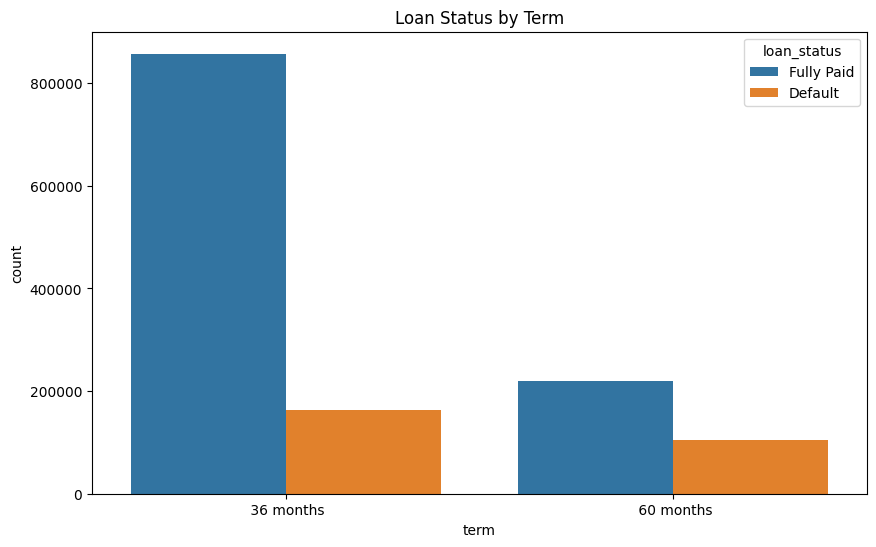

In [29]:
plt.figure(figsize=(10, 6))
sns.countplot(x='term', data=data, hue='loan_status')
plt.title('Loan Status by Term')
plt.show()

## Home ownership vs status

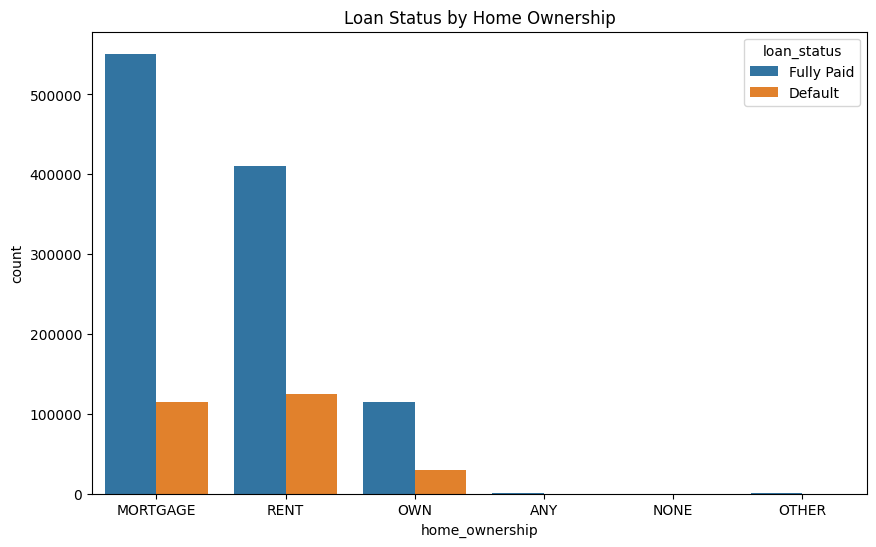

In [30]:
# Plot for 'home_ownership'
plt.figure(figsize=(10, 6))
sns.countplot(x='home_ownership', data=data, hue='loan_status')
plt.title('Loan Status by Home Ownership')
plt.show()

In [33]:
# make pandas dataframe of default rate for each category in 'home_ownership'
X.groupby('home_ownership')['loan_status'].value_counts(normalize=True).loc[:,'Default'].sort_values(ascending=False)

home_ownership
RENT        0.232187
OWN         0.206241
ANY         0.195804
OTHER       0.187500
MORTGAGE    0.172098
NONE        0.145833
Name: proportion, dtype: float64

## Purpose vs Loan Status

/var/folders/pg/r39s25yx6vn60b24nh6592th0000gn/T/ipykernel_11451/174928487.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(g.get_xticklabels(), rotation=90)


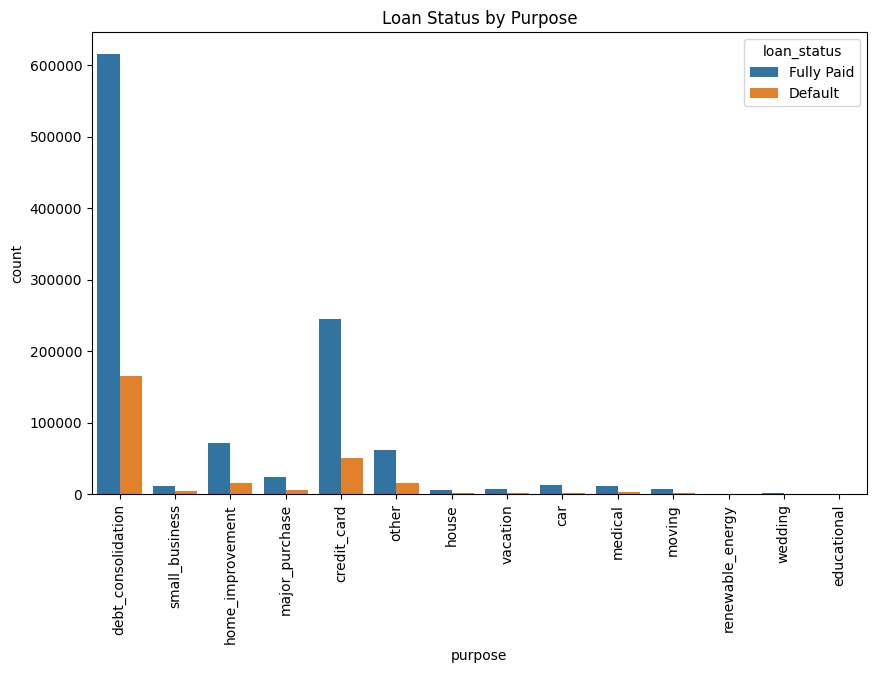

In [31]:
# Plot for 'purpose'
plt.figure(figsize=(10, 6))
g = sns.countplot(x='purpose', data=data, hue='loan_status')
g.set_xticklabels(g.get_xticklabels(), rotation=90)
plt.title('Loan Status by Purpose')
plt.show()

In [32]:
# make pandas dataframe of default rate for each category in 'purpose'
X.groupby('purpose')['loan_status'].value_counts(normalize=True).loc[:,'Default'].sort_values(ascending=False)

purpose
small_business        0.297094
renewable_energy      0.236870
moving                0.233544
house                 0.218914
medical               0.217858
debt_consolidation    0.211491
other                 0.210422
vacation              0.191726
major_purchase        0.186054
home_improvement      0.177186
educational           0.171779
credit_card           0.169287
car                   0.146970
wedding               0.121622
Name: proportion, dtype: float64

## Loan status by state

In [34]:
X.groupby('addr_state')['loan_status'].value_counts(normalize=True).loc[:,'Default'].sort_values(ascending=False)

addr_state
MS    0.260777
NE    0.251813
AR    0.240868
AL    0.236321
OK    0.234753
LA    0.231821
NY    0.220484
NV    0.219223
FL    0.214787
IN    0.214082
TN    0.214079
NM    0.213665
SD    0.213227
MD    0.213110
MO    0.212972
NJ    0.211228
KY    0.209829
PA    0.207956
NC    0.207860
OH    0.205319
ND    0.204744
MI    0.202957
HI    0.202131
VA    0.199422
TX    0.198252
DE    0.197462
MN    0.197430
AK    0.196552
AZ    0.196348
CA    0.196108
MA    0.190528
ID    0.188277
GA    0.183927
WI    0.183510
IL    0.181022
RI    0.178815
CT    0.173805
UT    0.170586
MT    0.168716
WY    0.167693
KS    0.167512
SC    0.162821
WA    0.157594
CO    0.155269
WV    0.155187
NH    0.145759
OR    0.144059
IA    0.142857
VT    0.139517
ME    0.138424
DC    0.132086
Name: proportion, dtype: float64

## Loan status by zip code

In [49]:
result = X.groupby('zip_code')['loan_status'].value_counts(normalize=True).loc[:, 'Default'].sort_values(ascending=False)
result_df = result.reset_index(name='Default Rate')

result_df.head(20)

,zip_code,Default Rate
0,643xx,1.000000
1,205xx,1.000000
2,516xx,1.000000
3,524xx,1.000000
4,889xx,1.000000
5,938xx,1.000000
6,682xx,1.000000
7,568xx,1.000000
8,513xx,1.000000
9,692xx,0.750000


## Drop unstructured categorical variables

In [48]:
# View number of unique values in each categorical variable
X.select_dtypes('object').nunique().sort_values(ascending=False)

url                          1345350
emp_title                     378358
title                          61681
zip_code                         943
addr_state                        51
sub_grade                         35
purpose                           14
grade                              7
home_ownership                     6
verification_status                3
verification_status_joint          3
application_type                   2
disbursement_method                2
initial_list_status                2
term                               2
loan_status                        2
dtype: int64

We will drop url, emp_title, and title, as they are unstructured and have too many unique values to encode effectively.

In [49]:
# Drop url, emp_title, and title
X.drop(['url', 'emp_title', 'title'], axis=1, inplace=True)

# Data Preprocessing

## Remove outliers

In [50]:
X.groupby('loan_status')['loan_amnt'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Default,268599.0,15564.874590,8814.794020,900.0,9000.0,14350.0,20400.0,40000.0
Fully Paid,1076751.0,14134.369808,8669.028973,500.0,7500.0,12000.0,20000.0,40000.0


In [51]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = X['loan_amnt'].quantile(0.25)
Q3 = X['loan_amnt'].quantile(0.75)
IQR = Q3 - Q1

# Define the bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = (X['loan_amnt'] < lower_bound) | (X['loan_amnt'] > upper_bound)

# Remove outliers
X_clean = X[~outliers]


In [52]:
X_clean.groupby('loan_status')['loan_amnt'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Default,267124.0,15430.215649,8650.273259,900.0,9000.0,14100.0,20000.0,38000.0
Fully Paid,1071067.0,13997.456065,8485.245965,500.0,7500.0,12000.0,20000.0,38000.0


## Impute Missing Values

In [53]:
# View summary statistics for CATEGORICAL columns with missing values
nan_cat_mean = X_clean.select_dtypes('object').isna().mean()
nan_cat_mean = nan_cat_mean[nan_cat_mean != 0].sort_values(ascending=False)
nan_cat_mean

verification_status_joint    9.817171e-01
zip_code                     7.472775e-07
dtype: float64

In [54]:
# View summary statistics for numerical columns with missing values
nan_num_mean = X_clean.select_dtypes(include='number').isna().mean()
nan_num_mean = nan_num_mean[nan_num_mean != 0].sort_values(ascending=False)
nan_num_mean

sec_app_mths_since_last_major_derog    9.952055e-01
sec_app_revol_util                     9.870564e-01
revol_bal_joint                        9.868165e-01
sec_app_fico_range_high                9.868158e-01
sec_app_open_acc                       9.868158e-01
                                           ...     
dti                                    2.622944e-04
collections_12_mths_ex_med             4.184754e-05
chargeoff_within_12_mths               4.184754e-05
tax_liens                              2.914382e-05
inq_last_6mths                         7.472775e-07
Length: 75, dtype: float64

Text(0, 0.5, 'Feature count')

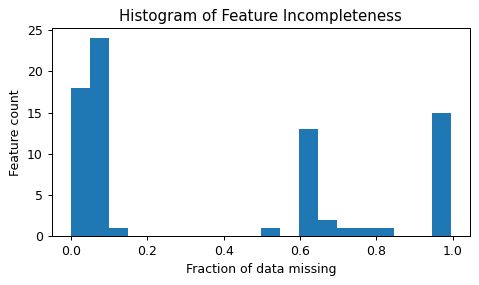

In [55]:
nan_mean = np.append(nan_num_mean, nan_cat_mean)
nan_mean_series = pd.Series(nan_mean)
plt.figure(figsize=(6,3), dpi=90)
nan_mean_series.plot.hist(bins=20)
plt.title('Histogram of Feature Incompleteness')
plt.xlabel('Fraction of data missing')
plt.ylabel('Feature count')

In order to judge how to handle missing values, we evaluated the feature definitions in "LCDataDictionary.xlsx". 

For categorical features, we replace missing values with empty strings. 

For some of the numeric features the missing values should be replaced with the maximum value of the column. For example, the feature `mths_since_last_record` indicates the number of months since the last record in credit history (like bankruptcy, foreclosure, tax liens, etc.). A missing value indicates that no records were made and the number of months since the "last" record should be a maximum.

For other numeric features, the missing values should be filled using the minimum value of the respective columns so these features are placed in the list `fill_min`. For example, the feature `emp_length` indicates the number of working years so if missing, one should assume that the borrower never worked and the number of working years should be a minimum.

In [56]:
# Identify columns with mixed data types
for column in X.columns:
    if X[column].apply(lambda x: isinstance(x, str)).any() and X[column].apply(lambda x: isinstance(x, (int, float))).any():
        print(f"Column '{column}' contains both string and numerical values.")

Column 'verification_status_joint' contains both string and numerical values.
Column 'zip_code' contains both string and numerical values.


In [57]:
# Convert mixed columns to string
X_clean['zip_code'] = X_clean['zip_code'].apply(str)
X_clean['verification_status_joint'] = X_clean['verification_status_joint'].apply(str)

/var/folders/pg/r39s25yx6vn60b24nh6592th0000gn/T/ipykernel_5460/3915504853.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_clean['zip_code'] = X_clean['zip_code'].apply(str)
/var/folders/pg/r39s25yx6vn60b24nh6592th0000gn/T/ipykernel_5460/3915504853.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_clean['verification_status_joint'] = X_clean['verification_status_joint'].apply(str)


In [58]:
print([column for column in X.columns if X[column].dtype == object])

['addr_state', 'application_type', 'disbursement_method', 'grade', 'home_ownership', 'initial_list_status', 'purpose', 'sub_grade', 'term', 'verification_status', 'verification_status_joint', 'zip_code', 'loan_status']


In [59]:
# convert term to int
X_clean['term'] = X_clean['term'].apply(lambda x: int(x.split()[0]))

/var/folders/pg/r39s25yx6vn60b24nh6592th0000gn/T/ipykernel_5460/1927538719.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_clean['term'] = X_clean['term'].apply(lambda x: int(x.split()[0]))


In [60]:
# Identify columns with mixed data types
for column in X_clean.columns:
    if X_clean[column].apply(lambda x: isinstance(x, str)).any() and X_clean[column].apply(lambda x: isinstance(x, (int, float))).any():
        print(f"Column '{column}' contains both string and numerical values.")

In [61]:
fill_empty = ['addr_state', 'application_type', 'disbursement_method', 'home_ownership', 'initial_list_status', 'purpose', 'grade',
                   'sub_grade','verification_status', 'verification_status_joint', 'zip_code', 'loan_status']
fill_max = ['bc_open_to_buy', 'mo_sin_old_il_acct', 'mths_since_last_delinq',
            'mths_since_last_major_derog', 'mths_since_last_record',
            'mths_since_rcnt_il', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq',
            'mths_since_recent_inq', 'mths_since_recent_revol_delinq',
            'pct_tl_nvr_dlq','sec_app_mths_since_last_major_derog']
fill_min = np.setdiff1d(X.columns.values, np.append(fill_empty, fill_max))

# Identify datetime columns
datetime_cols = X_clean.select_dtypes(include=['datetime64']).columns.tolist()

# Exclude datetime columns from fill_max and fill_min
fill_max = [col for col in fill_max if col not in datetime_cols]
fill_min = [col for col in fill_min if col not in datetime_cols]

# Ensure all columns are of the correct type before filling
X_clean[fill_empty] = X_clean[fill_empty].apply(lambda x: x.astype(str))
X_clean[fill_max] = X_clean[fill_max].apply(lambda x: x.astype(float))
X_clean[fill_min] = X_clean[fill_min].apply(lambda x: x.astype(float))

# Fill missing values
X_clean[fill_empty] = X_clean[fill_empty].fillna('')
X_clean[fill_max] = X_clean[fill_max].fillna(X[fill_max].max())
X_clean[fill_min] = X_clean[fill_min].fillna(X[fill_min].min())

/var/folders/pg/r39s25yx6vn60b24nh6592th0000gn/T/ipykernel_5460/2076041436.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_clean[fill_empty] = X_clean[fill_empty].apply(lambda x: x.astype(str))
/var/folders/pg/r39s25yx6vn60b24nh6592th0000gn/T/ipykernel_5460/2076041436.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_clean[fill_max] = X_clean[fill_max].apply(lambda x: x.astype(float))
/var/folders/pg/r39s25yx6vn60b24nh6592th0000gn/T/ipykernel_5460/2076041436.py:20: SettingWithCopyWarning: 
A val

In [62]:
# columns of X_clean that have positive nan
X_clean.isna().sum()[X_clean.isna().sum() > 0]

Series([], dtype: int64)

## Encode categorical variables

In [63]:
print([column for column in X_clean.columns if X_clean[column].dtype == object])

['addr_state', 'application_type', 'disbursement_method', 'grade', 'home_ownership', 'initial_list_status', 'purpose', 'sub_grade', 'verification_status', 'verification_status_joint', 'zip_code', 'loan_status']


In [64]:
# We drop the grade column because it provides less information than the sub_grade column.
X_clean.drop('grade', axis=1, inplace=True)

/var/folders/pg/r39s25yx6vn60b24nh6592th0000gn/T/ipykernel_5460/2620158731.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_clean.drop('grade', axis=1, inplace=True)


In [65]:
# convert loan_status to binary int type
X_clean['loan_status'] = X_clean['loan_status'].map({'Fully Paid': 0, 'Default': 1}).astype(int)

/var/folders/pg/r39s25yx6vn60b24nh6592th0000gn/T/ipykernel_5460/2608647477.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_clean['loan_status'] = X_clean['loan_status'].map({'Fully Paid': 0, 'Default': 1}).astype(int)


In [66]:
# nan count of loan status
X_clean['loan_status'].isna().sum()

0

### Dummy variables

In [67]:
X_clean = pd.get_dummies(
    X_clean, columns=['addr_state', 'application_type', 'disbursement_method', 'home_ownership', 'initial_list_status', 'purpose',
                   'sub_grade','verification_status', 'verification_status_joint', 'zip_code'],
      drop_first=True)

# Normalization

In [68]:
# Select only numerical columns
numerical_cols = X_clean.select_dtypes(include=['number']).columns
# take loan status out of numerical cols
numerical_cols = np.setdiff1d(numerical_cols, 'loan_status')

# Normalize numerical columns
X_clean[numerical_cols] = (X_clean[numerical_cols] - X_clean[numerical_cols].mean()) / X_clean[numerical_cols].std()

X_clean.head()

,acc_now_delinq,acc_open_past_24mths,all_util,annual_inc,annual_inc_joint,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,collections_12_mths_ex_med,...,zip_code_991xx,zip_code_992xx,zip_code_993xx,zip_code_994xx,zip_code_995xx,zip_code_996xx,zip_code_997xx,zip_code_998xx,zip_code_999xx,zip_code_nan
0,-0.065529,-0.162036,0.346834,-0.300861,-0.120046,0.497830,-0.290915,-0.661066,-0.082791,-0.116766,...,False,False,False,False,False,False,False,False,False,False
1,-0.065529,-0.162036,0.187623,-0.156447,-0.120046,-0.187339,0.195781,-0.993930,-0.082791,-0.116766,...,False,False,False,False,False,False,False,False,False,False
2,-0.065529,0.454071,1.333940,-0.185330,3.654726,1.179751,-0.280278,-0.044774,-0.082791,-0.116766,...,False,False,False,False,False,False,False,False,False,False
4,-0.065529,1.686285,1.747888,0.413017,-0.120046,0.931558,-0.264465,0.667093,-0.082791,-0.116766,...,False,False,False,False,False,False,False,False,False,False
5,-0.065529,-1.394250,1.684203,-0.604128,-0.120046,-0.635435,-0.296635,1.112009,-0.082791,-0.116766,...,False,False,False,False,False,False,False,False,False,False


In [69]:
X_clean.to_csv('data/processed_data.csv', index=False)